Diabetes Prediction using Support Vector Machine

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import joblib

In [4]:
df = pd.read_csv(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\supervised_machine_learning\SupportVectorMachine\datasets\pima.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

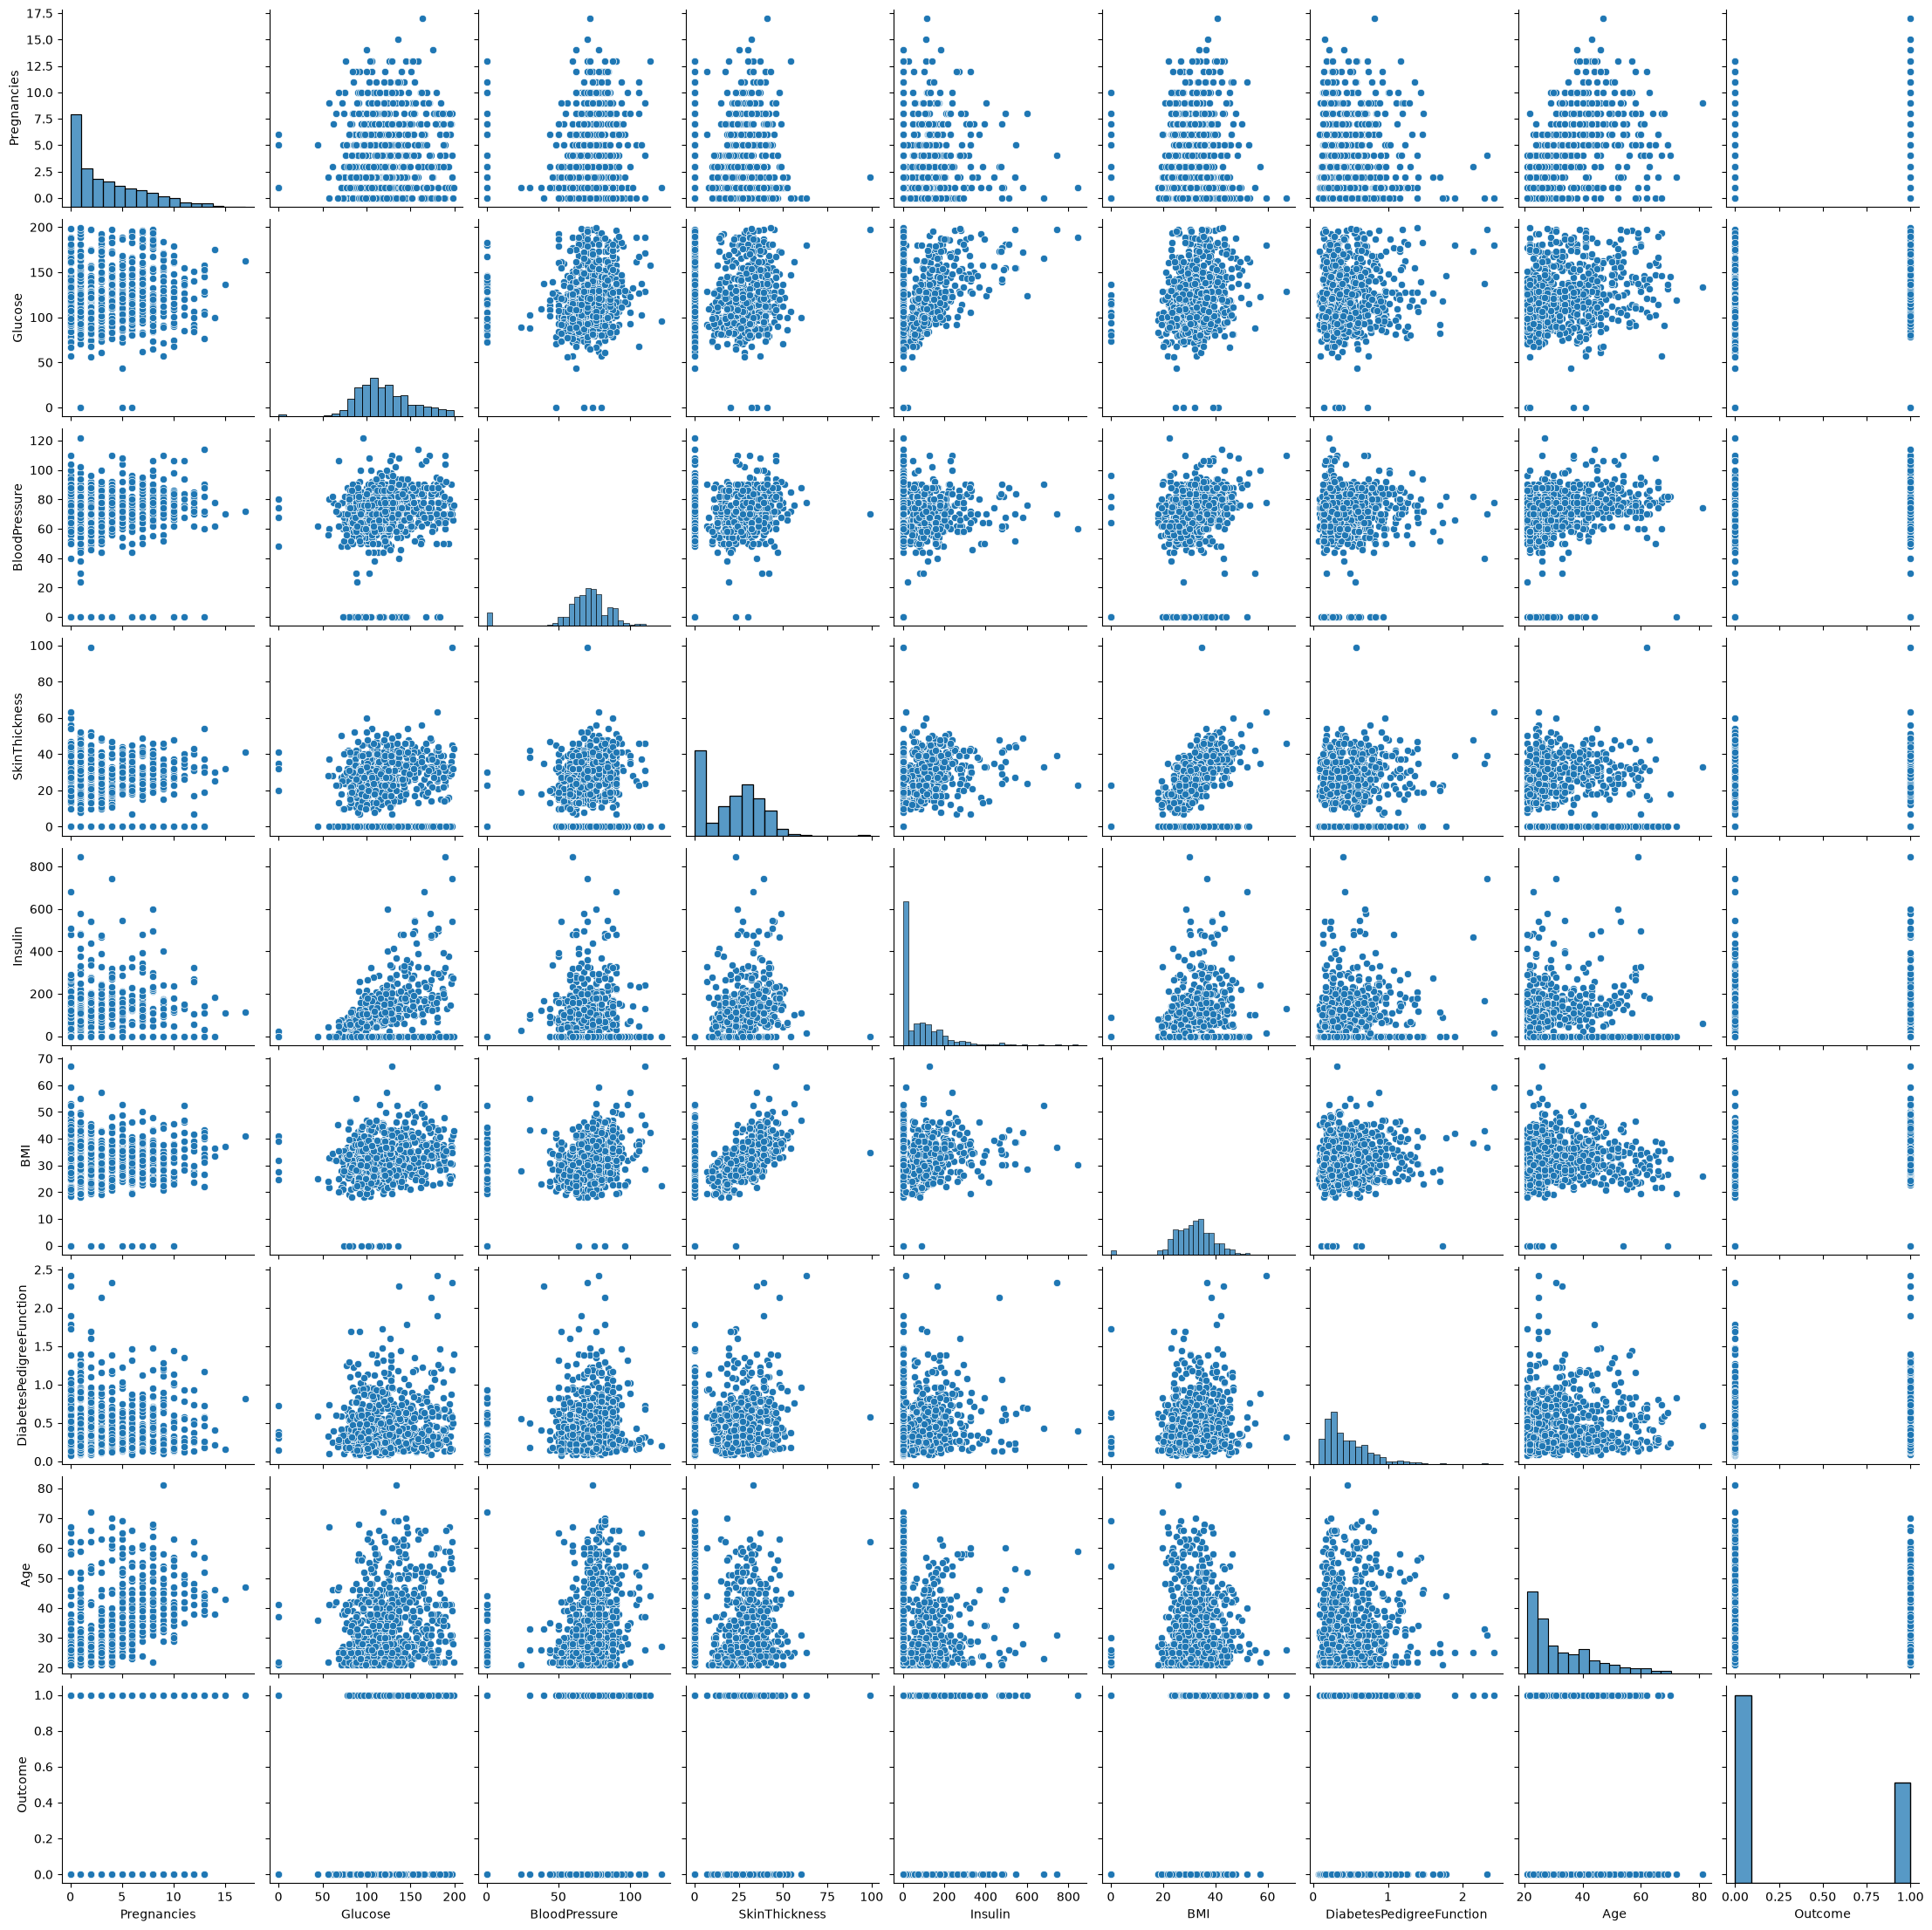

In [10]:
sns.pairplot(data=df)
plt.show()

In [11]:
zero_counts=(df == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


<Axes: >

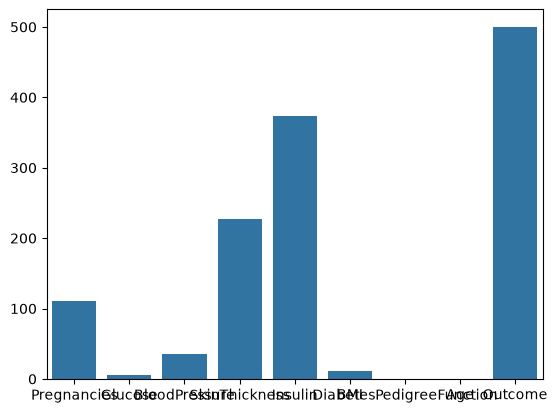

In [12]:
sns.barplot(data=zero_counts)


In [13]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

In [14]:
for col in invalid_zero_columns:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


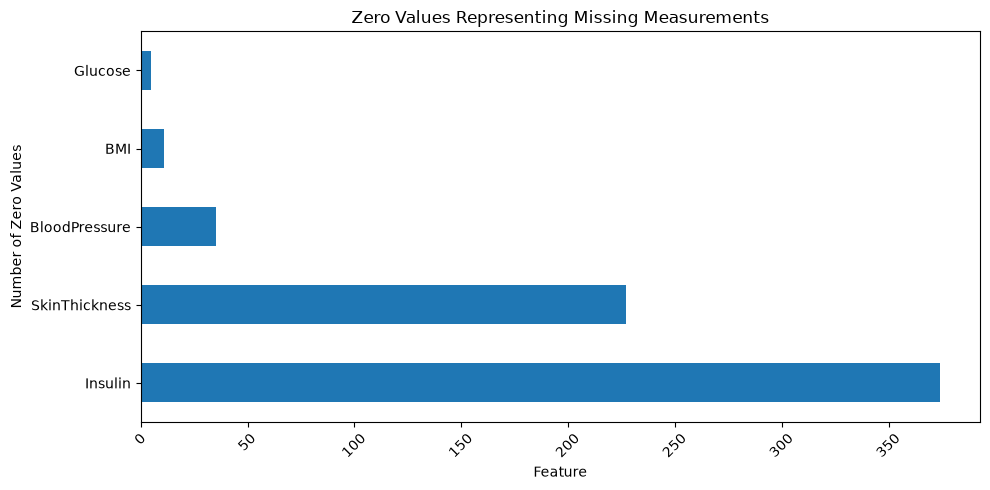

In [16]:
plt.figure(figsize=(10, 5))

zero_counts[invalid_zero_columns].sort_values(
    ascending=False
).plot(kind="barh")

plt.title("Zero Values Representing Missing Measurements")
plt.xlabel("Feature")
plt.ylabel("Number of Zero Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
df[invalid_zero_columns] = df[invalid_zero_columns].replace(
    0,
    np.nan
)

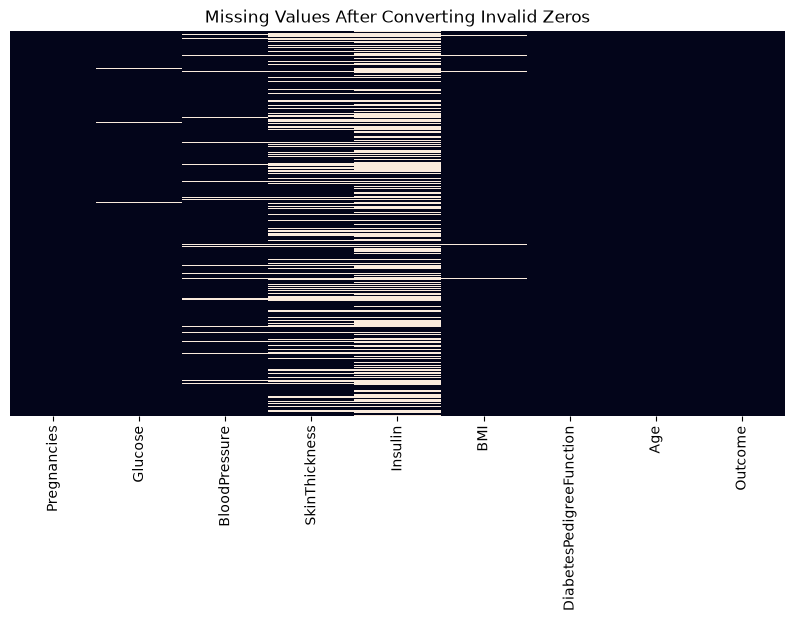

In [18]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values After Converting Invalid Zeros")
plt.show()

In [19]:
for col in invalid_zero_columns:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df= df.drop_duplicates()

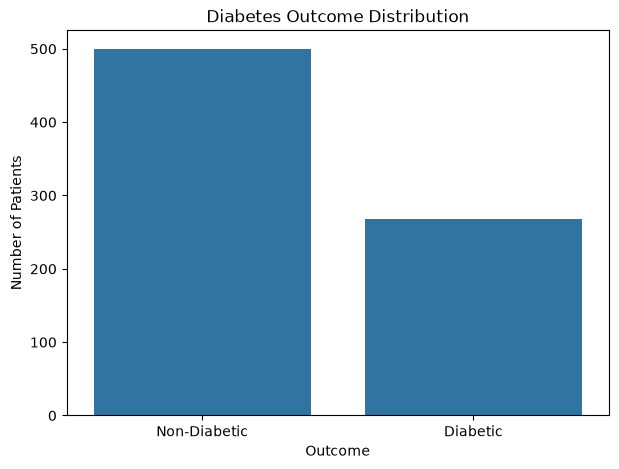

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["Non-Diabetic", "Diabetic"]
)

plt.show()

In [22]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

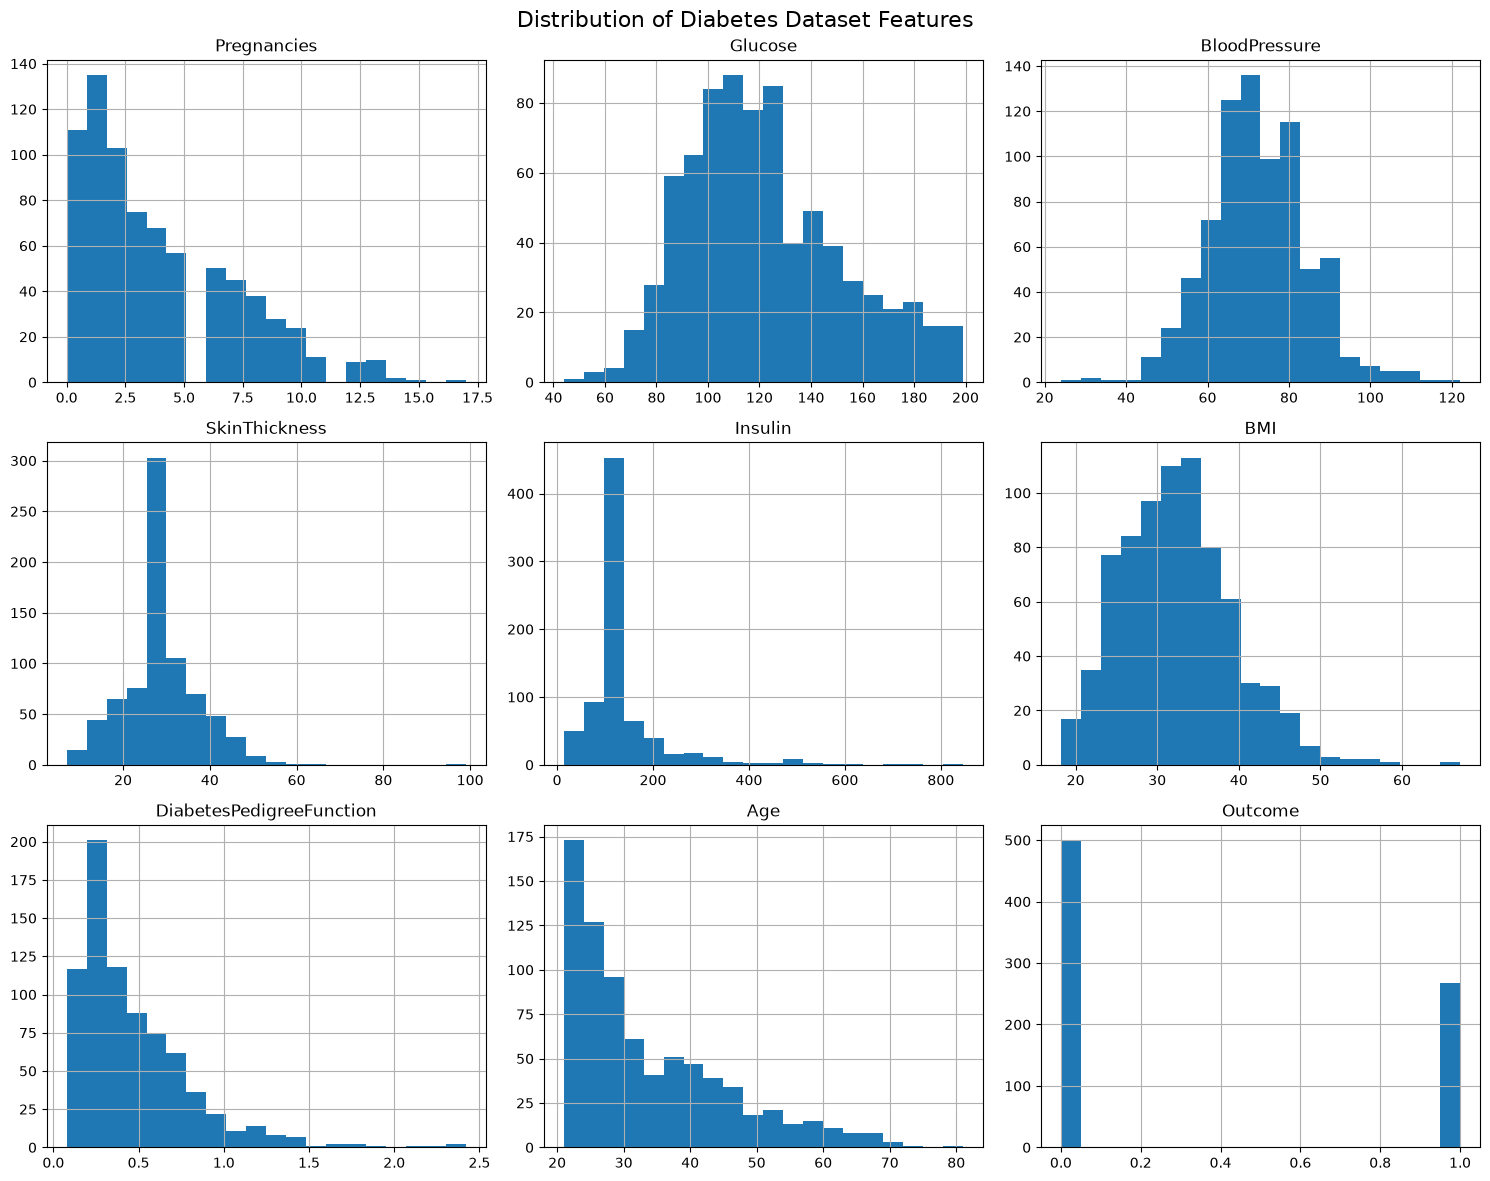

In [23]:
df.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Diabetes Dataset Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

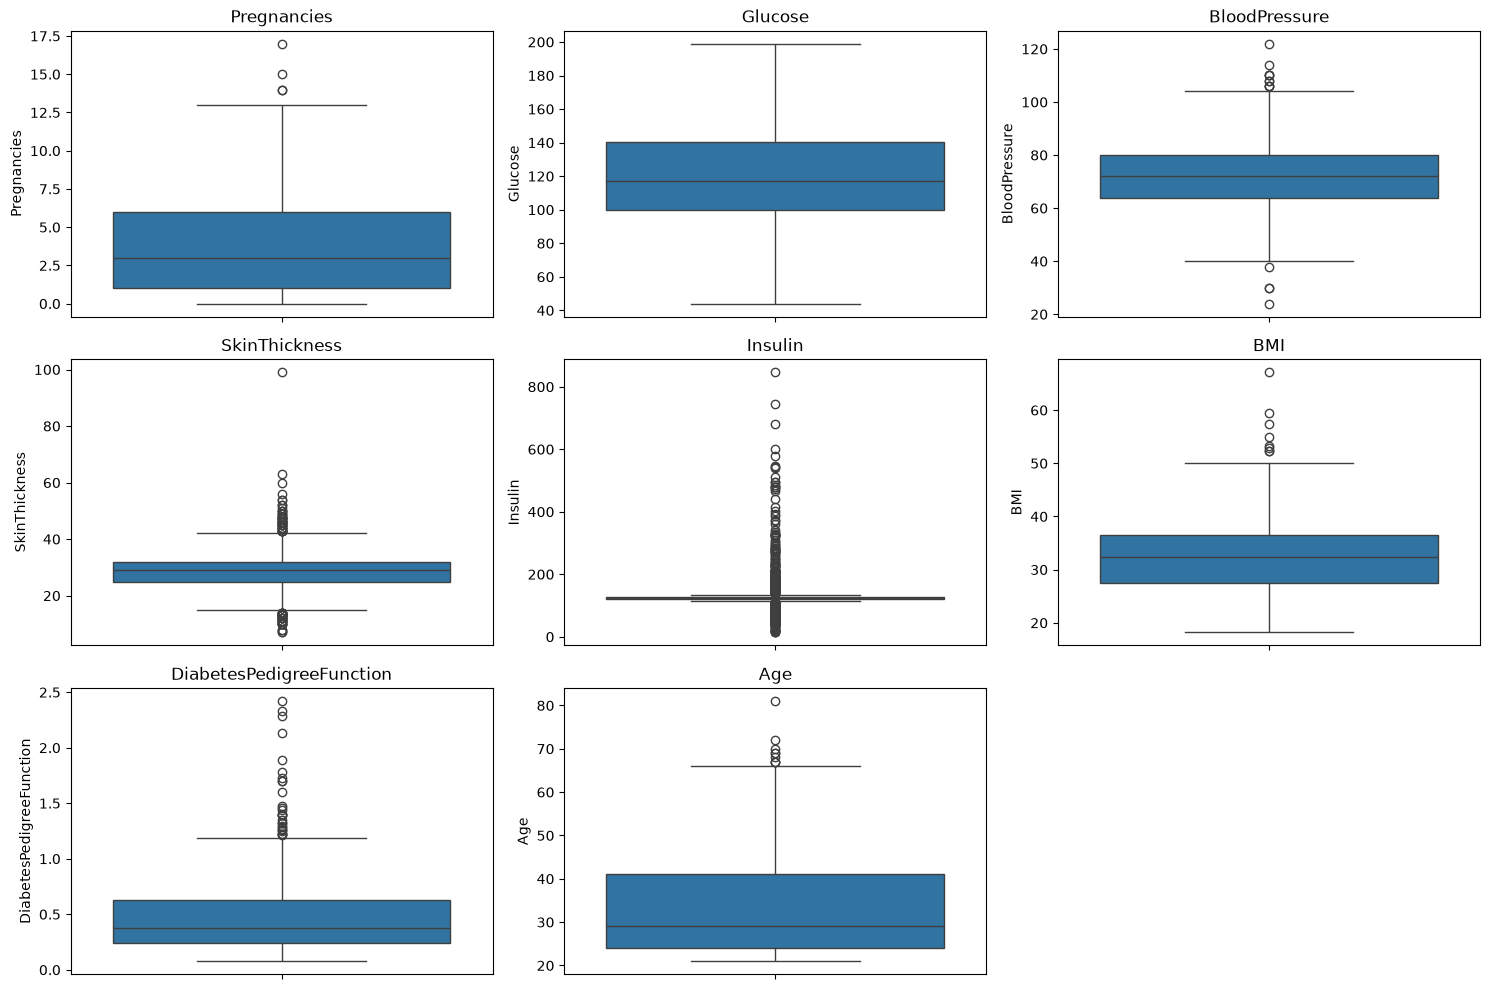

In [24]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(df.columns[:-1], 1):

    plt.subplot(3, 3, i)

    sns.boxplot(
        y=df[column]
    )

    plt.title(column)

plt.tight_layout()
plt.show()

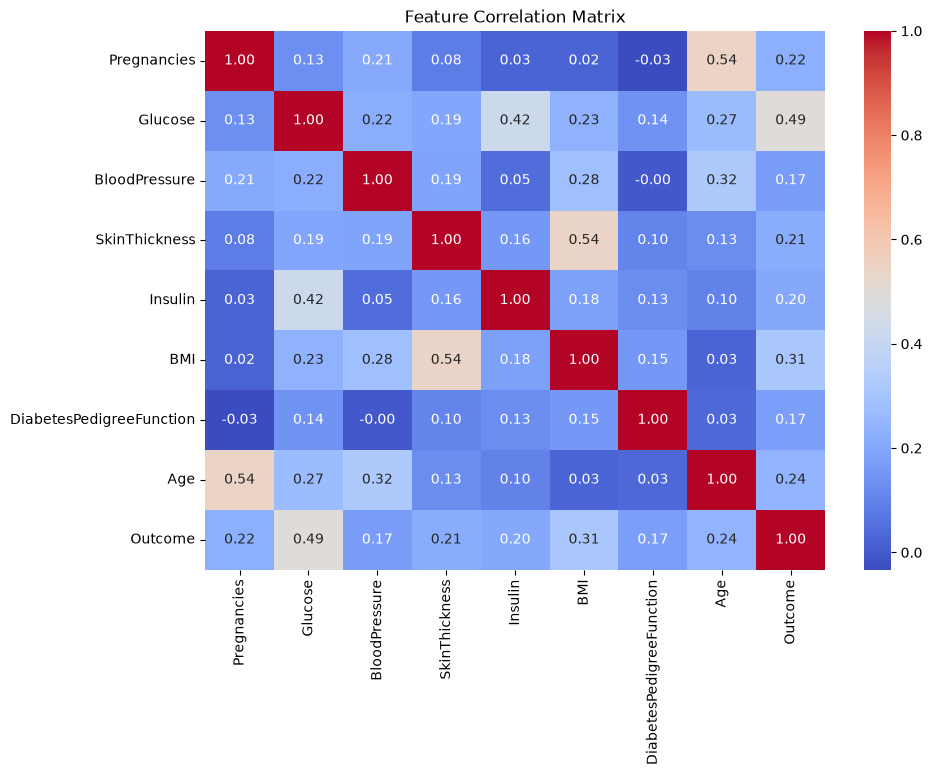

In [25]:
plt.figure(figsize=(10, 7))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

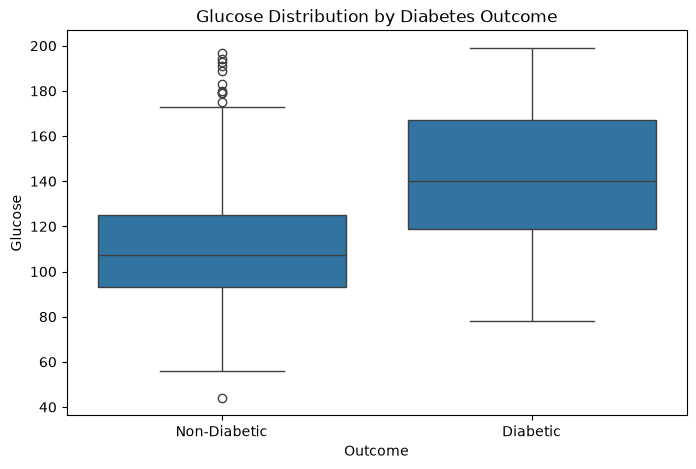

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Distribution by Diabetes Outcome")

plt.xticks(
    [0, 1],
    ["Non-Diabetic", "Diabetic"]
)

plt.show()

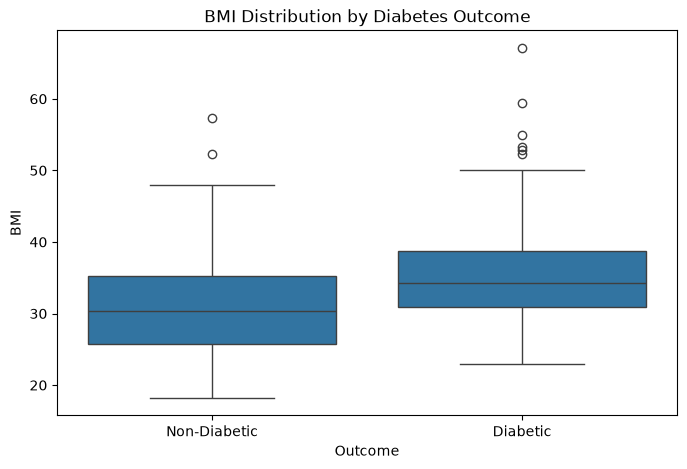

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="BMI"
)

plt.title("BMI Distribution by Diabetes Outcome")

plt.xticks(
    [0, 1],
    ["Non-Diabetic", "Diabetic"]
)

plt.show()

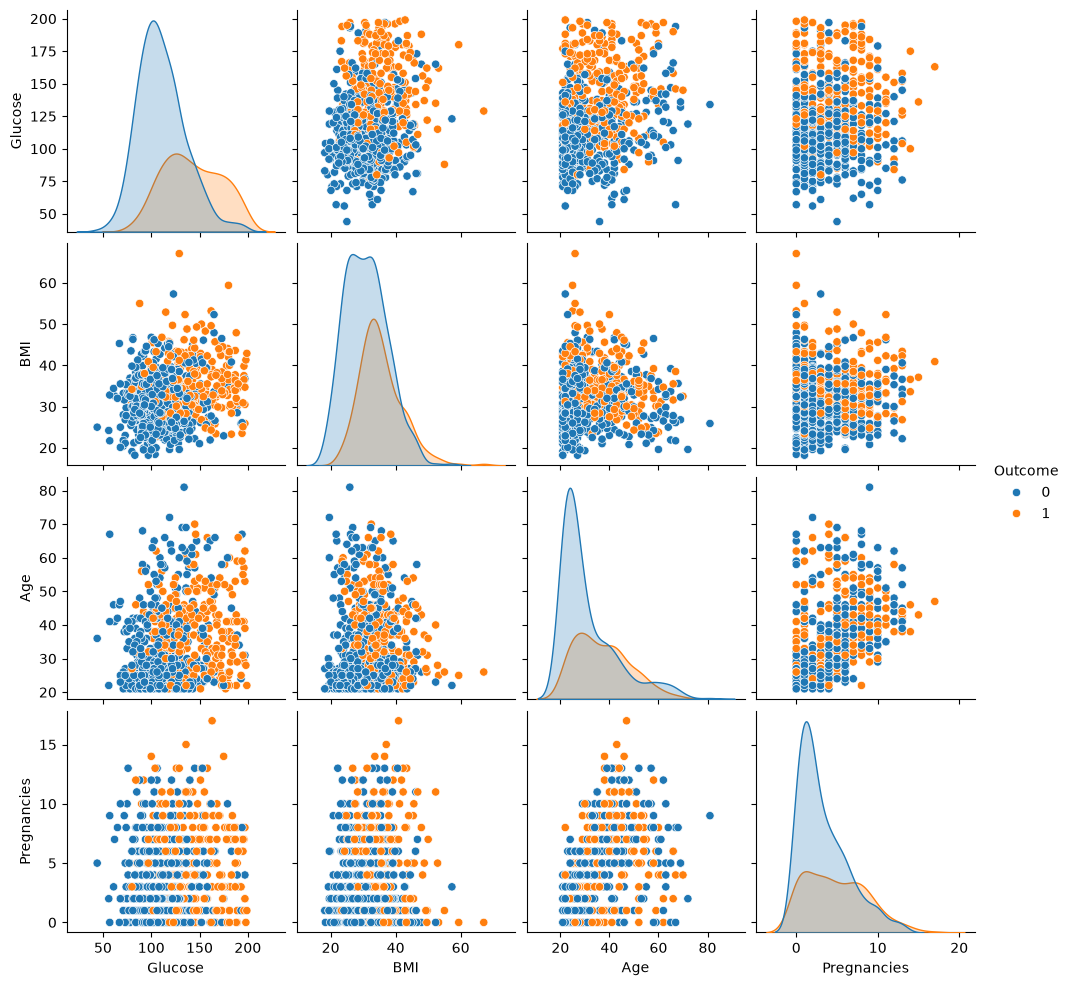

In [28]:
selected_features = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies",
    "Outcome"
]

sns.pairplot(
    df[selected_features],
    hue="Outcome"
)

plt.show()

In [29]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.96054099,  1.24515673, -0.66367599, ..., -0.74014536,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79026591,  2.76066903, ...,  0.44778472,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.01097389,  0.3147083 , ...,  0.50644793,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.32327781, -1.64206028, ..., -0.57882152,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07906404,  0.47777235, ...,  0.66777177,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69019703,  0.47777235, ...,  0.11047124,
        -0.16794879, -1.04589487]], shape=(154, 8))

In [33]:
linear_svm = SVC(
    kernel="linear"
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [34]:
y_pred_linear = linear_svm.predict(X_test_scaled)

In [35]:
accuracy_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print("Linear SVM Accuracy:", accuracy_linear)

Linear SVM Accuracy: 0.7012987012987013


In [36]:
print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=[
            "Non-Diabetic",
            "Diabetic"
        ]
    )
)

              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



In [37]:
cm = confusion_matrix(
    y_test,
    y_pred_linear
)

print(cm)

[[82 18]
 [28 26]]


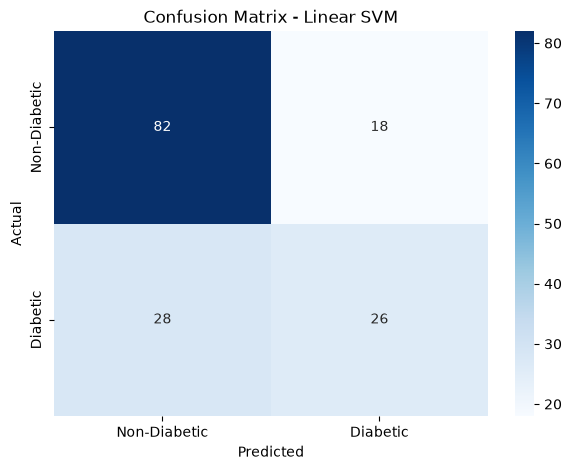

In [38]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-Diabetic",
        "Diabetic"
    ],
    yticklabels=[
        "Non-Diabetic",
        "Diabetic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [39]:
rbf_svm = SVC(
    kernel="rbf"
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

y_pred_rbf = rbf_svm.predict(
    X_test_scaled
)

In [40]:
print(
    classification_report(
        y_test,
        y_pred_rbf,
        target_names=[
            "Non-Diabetic",
            "Diabetic"
        ]
    )
)

              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [43]:
poly_svm = SVC(
    kernel="poly",
    degree=3
)

poly_svm.fit(
    X_train_scaled,
    y_train
)

y_pred_poly = poly_svm.predict(
    X_test_scaled
)

In [41]:
print(
    classification_report(
        y_test,
        y_pred_rbf,
        target_names=[
            "Non-Diabetic",
            "Diabetic"
        ]
    )
)


              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM",
        "Polynomial SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly)
    ]
})

results

,Model,Accuracy
0,Linear SVM,0.701299
1,RBF SVM,0.740260
2,Polynomial SVM,0.714286


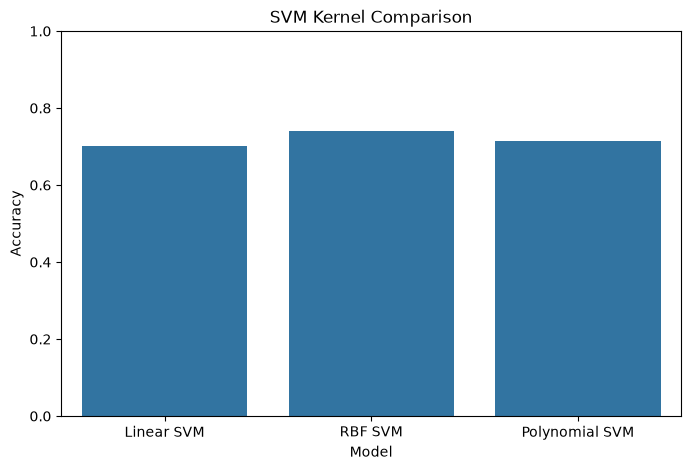

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("SVM Kernel Comparison")

plt.ylabel("Accuracy")

plt.show()

In [46]:
y_score = rbf_svm.decision_function(
    X_test_scaled
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_score
)

In [47]:
auc_score = roc_auc_score(
    y_test,
    y_score
)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.7962962962962963


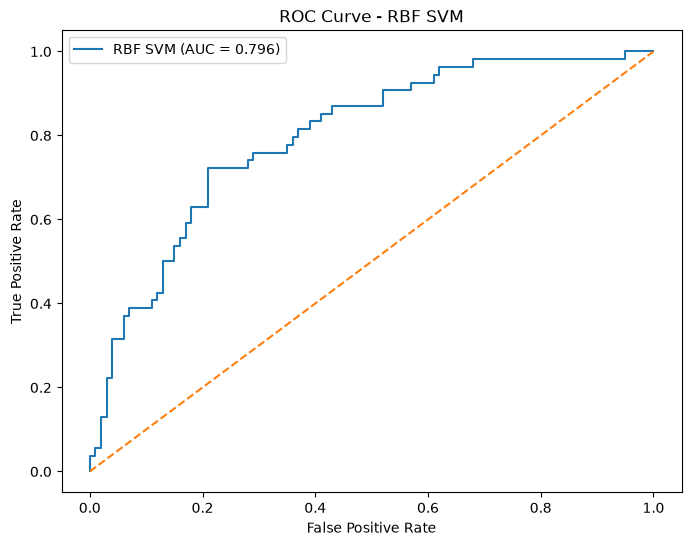

In [48]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"RBF SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - RBF SVM")

plt.legend()

plt.show()

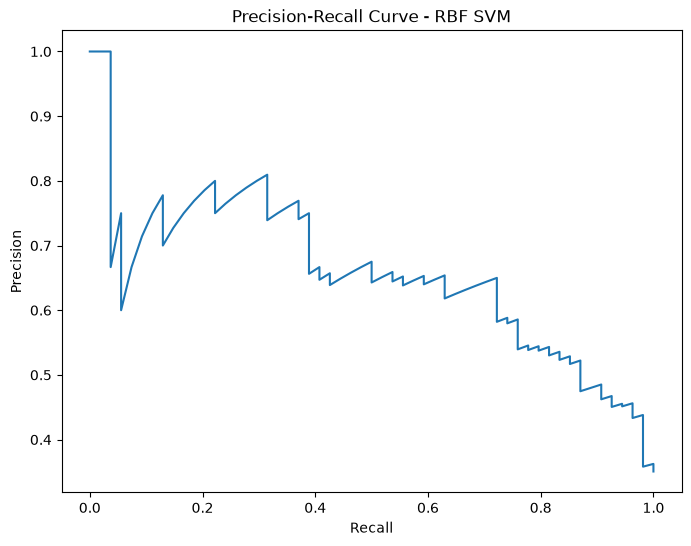

In [49]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_score
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - RBF SVM")

plt.show()